# Consumer Complaint Classification — SimpleRNN vs LSTM vs GRU vs Fine-tuned Transformer

In [1]:
!pip install -q kagglehub transformers datasets evaluate accelerate imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.0 MB/s eta 0:00:00


In [2]:
import os, re, string, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("models", exist_ok=True)

## 1. Load dataset

In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download("shashwatwork/consume-complaints-dataset-fo-nlp")
print(dataset_path)
for f in os.listdir(dataset_path):
    print(f)

100%|██████████| 19.8M/19.8M [00:00<00:00, 89.2MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1
complaints_processed.csv


In [4]:
csv_name = [f for f in os.listdir(dataset_path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(dataset_path, csv_name))
print(df.shape)
df.head()

(162421, 3)


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [5]:
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print(df.columns.tolist())

['unnamed:_0', 'product', 'narrative']


## 2. Consolidate to 5 product classes

In [6]:
CLASS_MAP = {
    "credit_reporting, credit repair services, or other personal consumer reports": "credit_reporting",
    "credit reporting, credit repair services, or other personal consumer reports": "credit_reporting",
    "credit reporting": "credit_reporting",
    "debt collection": "debt_collection",
    "mortgage": "mortgages_and_loans",
    "mortgages_and_loans": "mortgages_and_loans",
    "vehicle loan or lease": "mortgages_and_loans",
    "student loan": "mortgages_and_loans",
    "payday loan, title loan, or personal loan": "mortgages_and_loans",
    "consumer loan": "mortgages_and_loans",
    "credit card": "credit_cards",
    "credit_card": "credit_cards",
    "credit card or prepaid card": "credit_cards",
    "bank account or service": "retail_banking",
    "checking or savings account": "retail_banking",
    "money transfer, virtual currency, or money service": "retail_banking",
    "money transfers": "retail_banking",
    "prepaid card": "retail_banking",
    "retail_banking": "retail_banking",
}

text_col = [c for c in df.columns if "narrative" in c or "complaint" in c and "text" not in c][0]
label_col = [c for c in df.columns if "product" in c][0]
print(text_col, label_col)

df[label_col] = df[label_col].str.strip().str.lower()
df["label"] = df[label_col].map(CLASS_MAP).fillna(df[label_col])
df = df[df["label"].isin(["credit_reporting","debt_collection","mortgages_and_loans","credit_cards","retail_banking"])]
df = df[[text_col, "label"]].rename(columns={text_col: "narrative"})
df = df.dropna(subset=["narrative"])
df = df[df["narrative"].str.strip().str.len() > 0].reset_index(drop=True)
print(df.shape)
df["label"].value_counts(normalize=True)

narrative product
(162411, 2)


,proportion
label,
credit_reporting,0.561366
debt_collection,0.142527
mortgages_and_loans,0.116926
credit_cards,0.095843
retail_banking,0.083338


## 3. EDA

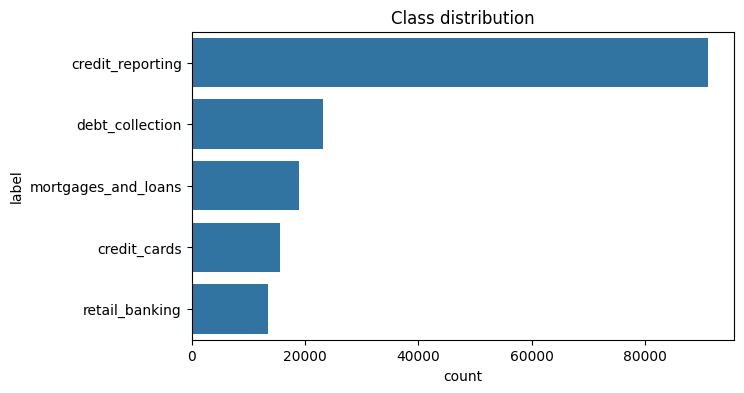

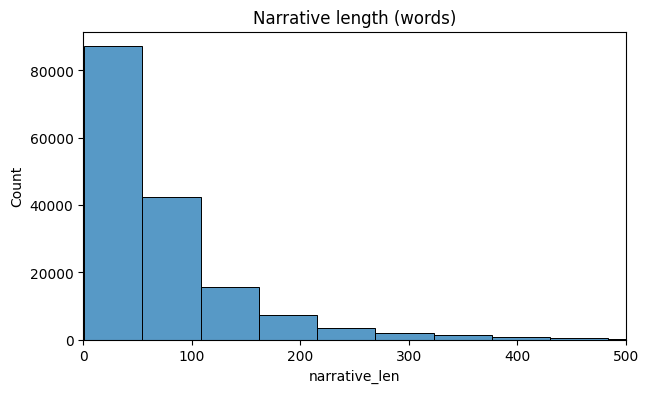

count    162411.000000
mean         80.232798
std         108.872213
min           1.000000
25%          27.000000
50%          50.000000
75%          95.000000
max        2685.000000
Name: narrative_len, dtype: float64


In [7]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, y="label", order=df["label"].value_counts().index)
plt.title("Class distribution")
plt.show()

df["narrative_len"] = df["narrative"].str.split().apply(len)
plt.figure(figsize=(7,4))
sns.histplot(df["narrative_len"], bins=50)
plt.xlim(0, 500)
plt.title("Narrative length (words)")
plt.show()
print(df["narrative_len"].describe())

## 4. Text preprocessing

In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"x{2,}", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.translate(PUNCT_TABLE)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 1]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

df["clean_narrative"] = df["narrative"].apply(clean_text)
df = df[df["clean_narrative"].str.len() > 0].reset_index(drop=True)
df[["narrative", "clean_narrative"]].head()

,narrative,clean_narrative
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


## 5. Encode labels and split

In [9]:
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])
NUM_CLASSES = len(le.classes_)
print(dict(zip(le.classes_, range(NUM_CLASSES))))

with open("models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["clean_narrative"], df["label_id"], test_size=0.2, stratify=df["label_id"], random_state=SEED
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)
print(len(X_train_text), len(X_val_text), len(X_test_text))

{'credit_cards': 0, 'credit_reporting': 1, 'debt_collection': 2, 'mortgages_and_loans': 3, 'retail_banking': 4}
129928 16241 16242


## 6. Class imbalance — class weights

In [10]:
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print(class_weight_dict)

{0: np.float64(2.086693969324661), 1: np.float64(0.3562745931420267), 2: np.float64(1.4032616913273572), 3: np.float64(1.7104791995787256), 4: np.float64(2.3998522349464353)}


## 7. Tokenization and padding

In [11]:
VOCAB_SIZE = 30000
MAX_LEN = 150
EMBED_DIM = 128

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

with open("models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = to_padded(X_train_text)
X_val = to_padded(X_val_text)
X_test = to_padded(X_test_text)

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat = to_categorical(y_val, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print(X_train.shape, X_val.shape, X_test.shape)

(129928, 150) (16241, 150) (16242, 150)


## 8. Model builders

In [12]:
def build_model(rnn_type):
    model = Sequential()
    model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
    if rnn_type == "simplernn":
        model.add(Bidirectional(SimpleRNN(64, return_sequences=True)))
        model.add(SimpleRNN(32))
    elif rnn_type == "lstm":
        model.add(Bidirectional(LSTM(64, return_sequences=True)))
        model.add(LSTM(32))
    elif rnn_type == "gru":
        model.add(Bidirectional(GRU(64, return_sequences=True)))
        model.add(GRU(32))
    model.add(Dropout(0.4))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.3))
    model.add(Dense(NUM_CLASSES, activation="softmax"))
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

## 9. Train + evaluate helper

In [13]:
results = {}

def train_and_eval(rnn_type, epochs=10, batch_size=128):
    model = build_model(rnn_type)
    ckpt_path = f"models/best_{rnn_type}.h5"
    callbacks = [
        ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=1),
        EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ]
    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=epochs, batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=callbacks, verbose=1,
    )
    best_model = load_model(ckpt_path)
    y_pred = np.argmax(best_model.predict(X_test), axis=1)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")
    print(f"\n{rnn_type.upper()} — acc={acc:.4f} prec={prec:.4f} rec={rec:.4f} f1={f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
    plt.title(f"Confusion Matrix — {rnn_type.upper()}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()

    results[rnn_type] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
    return history

## 10. Train SimpleRNN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2739 - loss: 1.6025
Epoch 1: val_accuracy improved from None to 0.56825, saving model to models/best_simplernn.h5



Epoch 1: finished saving model to models/best_simplernn.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 61s 44ms/step - accuracy: 0.3105 - loss: 1.5883 - val_accuracy: 0.5683 - val_loss: 1.5762 - learning_rate: 0.0010
Epoch 2/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3762 - loss: 1.5677
Epoch 2: val_accuracy did not improve from 0.56825
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.3845 - loss: 1.5657 - val_accuracy: 0.5184 - val_loss: 1.5027 - learning_rate: 0.0010
Epoch 3/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3857 - loss: 1.5279
Epoch 3: val_accuracy did not improve from 0.56825
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.4019 - loss: 1.5153 - val_accuracy: 0.5202 - val_loss: 1.4624 - learning_rate: 0.0010
Epoch 4/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4326 - loss: 1.4955
Epoch 4: val_accuracy did not improve from 0.56825
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.4072 - loss: 1.5259 - val_

508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step

SIMPLERNN — acc=0.5670 prec=0.4553 rec=0.5670 f1=0.4652
                     precision    recall  f1-score   support

       credit_cards       0.17      0.02      0.03      1557
   credit_reporting       0.60      0.95      0.74      9118
    debt_collection       0.26      0.06      0.10      2315
mortgages_and_loans       0.39      0.18      0.24      1899
     retail_banking       0.22      0.05      0.09      1353

           accuracy                           0.57     16242
          macro avg       0.33      0.25      0.24     16242
       weighted avg       0.46      0.57      0.47     16242



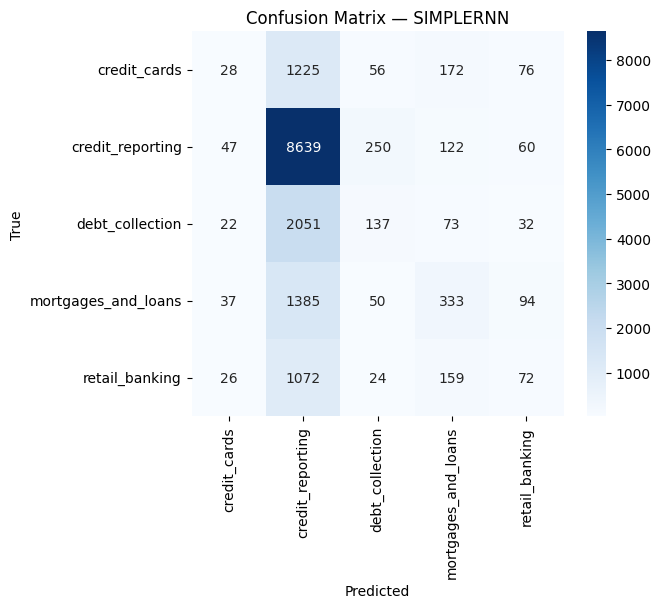

In [14]:
history_rnn = train_and_eval("simplernn")

## 11. Train LSTM

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3487 - loss: 1.5526
Epoch 1: val_accuracy improved from None to 0.67804, saving model to models/best_lstm.h5



Epoch 1: finished saving model to models/best_lstm.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.4300 - loss: 1.4285 - val_accuracy: 0.6780 - val_loss: 1.0287 - learning_rate: 0.0010
Epoch 2/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6398 - loss: 0.9759
Epoch 2: val_accuracy improved from 0.67804 to 0.76504, saving model to models/best_lstm.h5



Epoch 2: finished saving model to models/best_lstm.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.6800 - loss: 0.8999 - val_accuracy: 0.7650 - val_loss: 0.6668 - learning_rate: 0.0010
Epoch 3/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7626 - loss: 0.7181
Epoch 3: val_accuracy improved from 0.76504 to 0.81054, saving model to models/best_lstm.h5



Epoch 3: finished saving model to models/best_lstm.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.7866 - loss: 0.6493 - val_accuracy: 0.8105 - val_loss: 0.5918 - learning_rate: 0.0010
Epoch 4/10
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8342 - loss: 0.5032
Epoch 4: val_accuracy improved from 0.81054 to 0.83954, saving model to models/best_lstm.h5



Epoch 4: finished saving model to models/best_lstm.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - accuracy: 0.8404 - loss: 0.4786 - val_accuracy: 0.8395 - val_loss: 0.5019 - learning_rate: 0.0010
Epoch 5/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8553 - loss: 0.4224
Epoch 5: val_accuracy improved from 0.83954 to 0.84262, saving model to models/best_lstm.h5



Epoch 5: finished saving model to models/best_lstm.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - accuracy: 0.8593 - loss: 0.4057 - val_accuracy: 0.8426 - val_loss: 0.4861 - learning_rate: 0.0010
Epoch 6/10
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8695 - loss: 0.3661
Epoch 6: val_accuracy did not improve from 0.84262
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - accuracy: 0.8722 - loss: 0.3541 - val_accuracy: 0.8382 - val_loss: 0.5170 - learning_rate: 0.0010
Epoch 7/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8812 - loss: 0.3194
Epoch 7: val_accuracy did not improve from 0.84262
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.8826 - loss: 0.3141 - val_accuracy: 0.8325 - val_loss: 0.5535 - learning_rate: 0.0010
Epoch 8/10
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8919 - loss: 0.2761
Epoch 8: val_accuracy improved from 0.84262 to 0.84939, saving model to models/best_lstm.h5



Epoch 8: finished saving model to models/best_lstm.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.8973 - loss: 0.2611 - val_accuracy: 0.8494 - val_loss: 0.5255 - learning_rate: 5.0000e-04
Epoch 9/10
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9034 - loss: 0.2410
Epoch 9: val_accuracy did not improve from 0.84939
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.9065 - loss: 0.2323 - val_accuracy: 0.8494 - val_loss: 0.5544 - learning_rate: 5.0000e-04
Epoch 10/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9129 - loss: 0.2124
Epoch 10: val_accuracy did not improve from 0.84939
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - accuracy: 0.9161 - loss: 0.2022 - val_accuracy: 0.8482 - val_loss: 0.5947 - learning_rate: 2.5000e-04


508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

LSTM — acc=0.8584 prec=0.8704 rec=0.8584 f1=0.8617
                     precision    recall  f1-score   support

       credit_cards       0.68      0.86      0.76      1557
   credit_reporting       0.95      0.87      0.91      9118
    debt_collection       0.76      0.80      0.78      2315
mortgages_and_loans       0.76      0.87      0.81      1899
     retail_banking       0.86      0.85      0.86      1353

           accuracy                           0.86     16242
          macro avg       0.80      0.85      0.82     16242
       weighted avg       0.87      0.86      0.86     16242



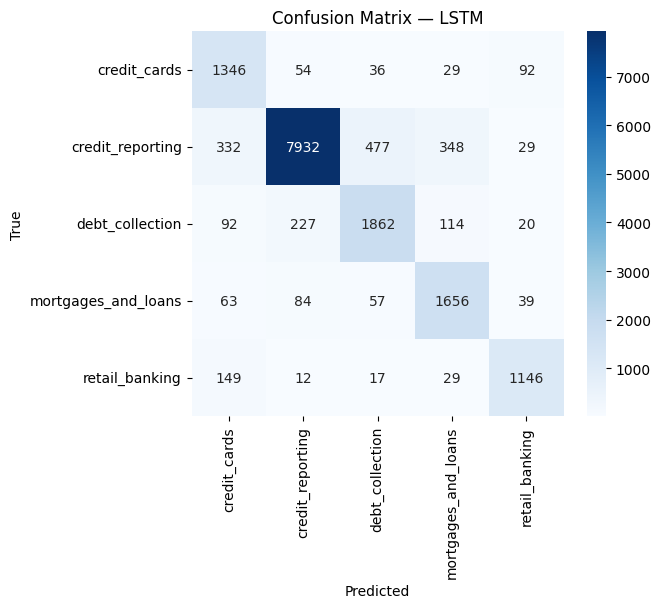

In [15]:
history_lstm = train_and_eval("lstm")

## 12. Train GRU

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3618 - loss: 1.3853
Epoch 1: val_accuracy improved from None to 0.49449, saving model to models/best_gru.h5



Epoch 1: finished saving model to models/best_gru.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.4715 - loss: 1.0755 - val_accuracy: 0.4945 - val_loss: 0.7814 - learning_rate: 0.0010
Epoch 2/10
1014/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7065 - loss: 0.5914
Epoch 2: val_accuracy improved from 0.49449 to 0.83757, saving model to models/best_gru.h5



Epoch 2: finished saving model to models/best_gru.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.7867 - loss: 0.5159 - val_accuracy: 0.8376 - val_loss: 0.4833 - learning_rate: 0.0010
Epoch 3/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8515 - loss: 0.4163
Epoch 3: val_accuracy improved from 0.83757 to 0.84311, saving model to models/best_gru.h5



Epoch 3: finished saving model to models/best_gru.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.8594 - loss: 0.3953 - val_accuracy: 0.8431 - val_loss: 0.4693 - learning_rate: 0.0010
Epoch 4/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8713 - loss: 0.3526
Epoch 4: val_accuracy did not improve from 0.84311
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.8758 - loss: 0.3396 - val_accuracy: 0.8401 - val_loss: 0.4962 - learning_rate: 0.0010
Epoch 5/10
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8860 - loss: 0.3044
Epoch 5: val_accuracy did not improve from 0.84311
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8908 - loss: 0.2906 - val_accuracy: 0.8428 - val_loss: 0.5266 - learning_rate: 0.0010
Epoch 6/10
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9032 - loss: 0.2496
Epoch 6: val_accuracy improved from 0.84311 to 0.84872, saving model to models/best_gru.h5



Epoch 6: finished saving model to models/best_gru.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.9096 - loss: 0.2340 - val_accuracy: 0.8487 - val_loss: 0.5616 - learning_rate: 5.0000e-04
Epoch 7/10
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9131 - loss: 0.2155
Epoch 7: val_accuracy improved from 0.84872 to 0.85697, saving model to models/best_gru.h5



Epoch 7: finished saving model to models/best_gru.h5
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.9186 - loss: 0.2032 - val_accuracy: 0.8570 - val_loss: 0.5568 - learning_rate: 5.0000e-04
Epoch 8/10
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9251 - loss: 0.1839
Epoch 8: val_accuracy did not improve from 0.85697
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.9300 - loss: 0.1727 - val_accuracy: 0.8569 - val_loss: 0.5788 - learning_rate: 2.5000e-04
Epoch 9/10
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9294 - loss: 0.1683
Epoch 9: val_accuracy did not improve from 0.85697
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.9335 - loss: 0.1592 - val_accuracy: 0.8551 - val_loss: 0.6108 - learning_rate: 2.5000e-04
Epoch 10/10
1014/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9368 - loss: 0.1495
Epoch 10: val_accuracy did not improve from 0.85697
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.9404 - loss: 0.142

508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

GRU — acc=0.8607 prec=0.8699 rec=0.8607 f1=0.8634
                     precision    recall  f1-score   support

       credit_cards       0.72      0.79      0.76      1557
   credit_reporting       0.95      0.88      0.91      9118
    debt_collection       0.75      0.82      0.79      2315
mortgages_and_loans       0.75      0.88      0.81      1899
     retail_banking       0.84      0.86      0.85      1353

           accuracy                           0.86     16242
          macro avg       0.80      0.85      0.82     16242
       weighted avg       0.87      0.86      0.86     16242



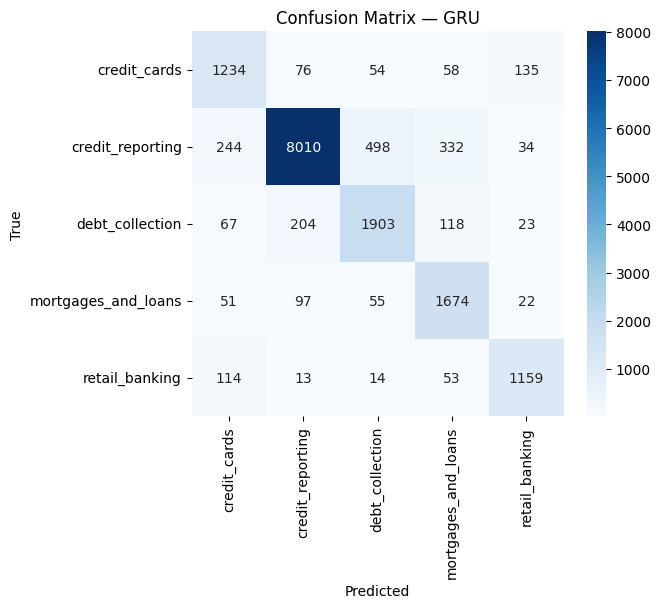

In [16]:
history_gru = train_and_eval("gru")

## 13. Fine-tune HuggingFace Transformer

In [18]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset
import evaluate

MODEL_NAME = "distilbert-base-uncased"

hf_train_df = pd.DataFrame({"text": X_train_text.values, "label": y_train.values})
hf_val_df = pd.DataFrame({"text": X_val_text.values, "label": y_val.values})
hf_test_df = pd.DataFrame({"text": X_test_text.values, "label": y_test.values})

hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return hf_tokenizer(batch["text"], truncation=True, max_length=150)

train_ds = Dataset.from_pandas(hf_train_df).map(tokenize_fn, batched=True)
val_ds = Dataset.from_pandas(hf_val_df).map(tokenize_fn, batched=True)
test_ds = Dataset.from_pandas(hf_test_df).map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=hf_tokenizer)

hf_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_CLASSES)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="models/transformer_ckpts",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available() if 'torch' in dir() else False,
    report_to="none",
)

import torch
trainer = Trainer(
    model=hf_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=hf_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Map:   0%|          | 0/129928 [00:00<?, ? examples/s]

Map:   0%|          | 0/16241 [00:00<?, ? examples/s]

Map:   0%|          | 0/16242 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.344202,0.346437,0.885844,0.884143
2,0.283316,0.316798,0.895881,0.895966
3,0.223371,0.340021,0.895327,0.894650


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=24363, training_loss=0.31065448099759607, metrics={'train_runtime': 1751.2591, 'train_samples_per_second': 222.574, 'train_steps_per_second': 13.912, 'total_flos': 1.493556473829816e+16, 'train_loss': 0.31065448099759607, 'epoch': 3.0})

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TRANSFORMER — acc=0.8981 prec=0.8982 rec=0.8981 f1=0.8980
                     precision    recall  f1-score   support

       credit_cards       0.81      0.84      0.83      1557
   credit_reporting       0.94      0.94      0.94      9118
    debt_collection       0.84      0.79      0.82      2315
mortgages_and_loans       0.84      0.88      0.86      1899
     retail_banking       0.90      0.88      0.89      1353

           accuracy                           0.90     16242
          macro avg       0.87      0.87      0.87     16242
       weighted avg       0.90      0.90      0.90     16242



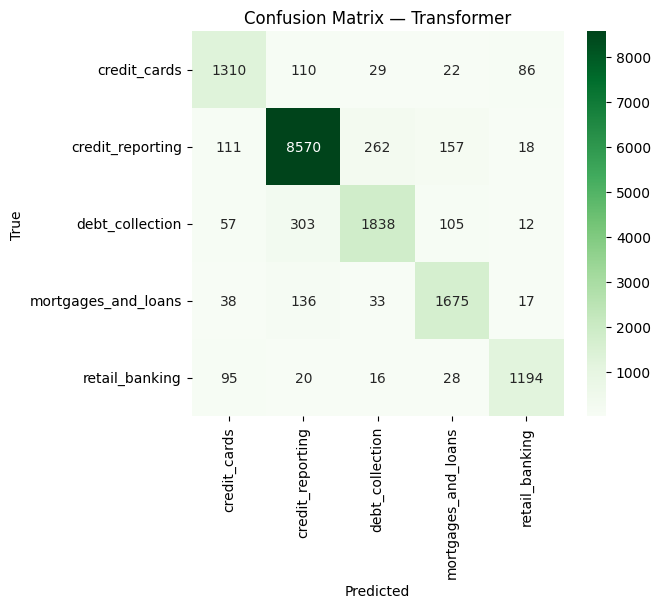

In [19]:
best_transformer_dir = "models/best_transformer"
trainer.save_model(best_transformer_dir)
hf_tokenizer.save_pretrained(best_transformer_dir)

test_preds = trainer.predict(test_ds)
y_pred_hf = np.argmax(test_preds.predictions, axis=-1)

acc = accuracy_score(y_test, y_pred_hf)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_hf, average="weighted")
print(f"TRANSFORMER — acc={acc:.4f} prec={prec:.4f} rec={rec:.4f} f1={f1:.4f}")
print(classification_report(y_test, y_pred_hf, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_hf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Greens")
plt.title("Confusion Matrix — Transformer")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

results["transformer"] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

## 14. Compare all four models

             accuracy  precision    recall        f1
transformer  0.898104   0.898179  0.898104  0.897950
gru          0.860731   0.869852  0.860731  0.863426
lstm         0.858392   0.870356  0.858392  0.861667
simplernn    0.566987   0.455275  0.566987  0.465185


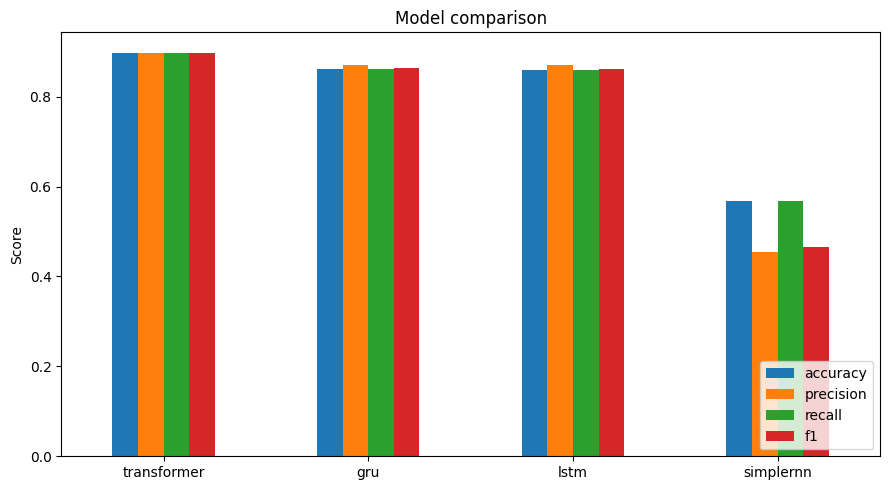

Best model: transformer


In [20]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("f1", ascending=False)
print(results_df)

results_df.plot(kind="bar", figsize=(9,5))
plt.title("Model comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

with open("models/results_summary.json", "w") as f:
    json.dump(results, f, indent=2)

best_model_name = results_df.index[0]
print("Best model:", best_model_name)

## 15. Inference on new complaints

In [21]:
def predict_complaint(text, model_type=None):
    model_type = model_type or best_model_name
    cleaned = clean_text(text)

    if model_type == "transformer":
        inputs = hf_tokenizer(cleaned, return_tensors="pt", truncation=True, max_length=150)
        with torch.no_grad():
            logits = AutoModelForSequenceClassification.from_pretrained(best_transformer_dir)(**inputs).logits
        pred_id = int(torch.argmax(logits, dim=-1))
    else:
        model = load_model(f"models/best_{model_type}.h5")
        padded = to_padded([cleaned])
        pred_id = int(np.argmax(model.predict(padded), axis=1)[0])

    return le.inverse_transform([pred_id])[0]

sample = "I have been trying to dispute an incorrect balance on my credit card statement for months and no one has responded."
print(predict_complaint(sample))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

credit_cards


## 16. Artifacts saved for deployment (Streamlit)

In [22]:
print(os.listdir("models"))
# models/tokenizer.pkl
# models/label_encoder.pkl
# models/best_simplernn.h5
# models/best_lstm.h5
# models/best_gru.h5
# models/best_transformer/ (HF save_pretrained dir)
# models/results_summary.json

['results_summary.json', 'label_encoder.pkl', 'best_simplernn.h5', 'tokenizer.pkl', 'best_transformer', 'best_lstm.h5', 'best_gru.h5', 'transformer_ckpts']
